# PINO pipeline for 2D Darcy problem

This extends the vanilla FNO with a physics-informed (PINO) training loop.

**What changed vs. the FNO notebook:**
- `Trainer` is replaced with a manual training loop that adds a PDE residual loss term.
- A `darcy_pde_residual()` function computes `‖−∇·(a∇u) − f‖²` using Fourier differentiation.
- `lambda_pde` weights the PDE loss relative to the H1 data loss.

In [159]:
# Imports
import numpy as np
import sys
import os

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern

import torch
from torch.utils.data import DataLoader

import neuralop
from neuralop.models import FNO
from neuralop import LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import DarcyDataset
from neuralop.utils import count_model_params
from torch.nn import functional as F

import matplotlib.pyplot as plt

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

N = 64
M = 256
L = 1.0


def sample_GP_operator(N=64, M=256):
    h_fine = 1 / M
    kx = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    ky = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    A_eigs = KX**2 + KY**2 + 9.0
    Cov_eigs = 1.0 / (A_eigs**2)
    z = np.random.randn(M, M) + 1j * np.random.randn(M, M)
    u_hat = np.sqrt(Cov_eigs) * z
    u_fine = np.fft.ifft2(u_hat).real * M**2
    step = M // N
    return u_fine[::step, ::step]


def sample_GP_operator_masked(u_current, bandwidth=0.1, smooth_sigma=2.0):
    xi = sample_GP_operator()
    mask = (np.abs(u_current) < bandwidth).astype(float)
    mask = gaussian_filter(mask, sigma=smooth_sigma)
    if mask.max() > 1e-8:
        mask = mask / (mask.std() + 1e-8)
    return xi * mask


def sample_GP_operator_mixed(u_current, bandwidth=0.1,
                               smooth_sigma=2.0, interface_weight=0.8):
    if np.random.rand() < interface_weight:
        return sample_GP_operator_masked(u_current, bandwidth, smooth_sigma)
    else:
        return sample_GP_operator()


In [161]:
# ===== HYPERPARAMETERS =====

# === Data ===
data_n_train = 1_000
data_n_tests = [100, 50]
data_train_resolution = 64  # options: 16, 32, 64, 128, 421
data_test_resolutions = [64, 128]
data_batch_size = 32
data_test_batch_sizes = [32, 32]

# === Model ===
FNO_n_modes=(12, 12)
FNO_in_channels=1
FNO_out_channels=1
FNO_hidden_channels=32
FNO_n_layers = 4
FNO_factorization="tucker"
FNO_nonlinearity= F.gelu

# === Training ===
TRAIN_epochs = 100

# === PINO-specific ===
# Weight of PDE loss relative to data (H1) loss.
# Start small; increase to 1e-1 or 1.0 if you want stronger physics enforcement.
lambda_pde = 1e-2

# Darcy forcing: f = 1 everywhere (as per the standard benchmark)
DARCY_FORCING = 1.0

In [162]:
def T_push(x, tau=-1, boundary=0):
    """Smooth (or hard) threshold to map GP samples to binary permeability fields."""
    if isinstance(x, np.ndarray):
        if tau == -1:
            return np.where(x < boundary, 3.0, 12.0)
        return 0.5 * np.tanh(tau * x) + 0.5
    else:
        if tau == -1:
            return torch.where(x < boundary,
                               torch.tensor(3.0),
                               torch.tensor(12.0))
        return 0.5 * torch.tanh(tau * x) + 0.5

In [163]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [164]:
# Import Data
dataset = DarcyDataset(
    root_dir="./darcy_data",
    n_train=data_n_train,
    n_tests=data_n_tests,
    train_resolution=data_train_resolution,
    batch_size=data_batch_size,
    test_resolutions=data_test_resolutions,
    test_batch_sizes=data_test_batch_sizes,
)

# Renormalise to 3-12 range (run once only)
for test_set in dataset.test_dbs.values():
    test_set.x = T_push(test_set.x, tau=-1, boundary=0.5)
dataset._train_db.x = T_push(dataset._train_db.x, tau=-1, boundary=0.5)

train_loader = DataLoader(
    dataset.train_db,
    batch_size=data_batch_size,
    num_workers=1,
    pin_memory=True,
    persistent_workers=False,
)

test_loaders = {}
for res, test_bsize in zip(data_test_resolutions, data_test_batch_sizes):
    test_loaders[res] = DataLoader(
        dataset.test_dbs[res],
        batch_size=test_bsize,
        shuffle=False,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

data_processor = dataset.data_processor

Loading test db for resolution 64 with 100 samples 
Loading test db for resolution 128 with 50 samples 


In [165]:
# Instantiate Model
model = FNO(
    n_modes=FNO_n_modes,
    in_channels=FNO_in_channels,
    out_channels=FNO_out_channels,
    hidden_channels=FNO_hidden_channels,
    n_layers=FNO_n_layers,
    factorization=FNO_factorization,
    non_linearity=FNO_nonlinearity,
)
model = model.to(device)

n_params = count_model_params(model)
print(f"\nModel has {n_params} parameters.")
sys.stdout.flush()

optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TRAIN_epochs)

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)


Model has 719209 parameters.


In [166]:
# ===========================================================================
# PINO: Darcy PDE residual via Fourier differentiation
# ===========================================================================
#
# Darcy's law (strong form):
#   -∇·(a(x) ∇u(x)) = f,   x ∈ (0,1)²
#   u = 0  on  ∂(0,1)²
#
# Expanding the divergence: -(∇a · ∇u + a Δu) = f
#
# We compute ∂_x u, ∂_y u, Δu = ∂_xx u + ∂_yy u  via the Fourier method:
#   û(k) → ik û(k)   for first derivative
#   û(k) → -k² û(k)  for second derivative
#
# The domain is [0,1]² with a Dirichlet zero boundary, so we use the
# Fourier sine transform (FST) which is exact for functions that vanish
# on the boundary. torch.fft.dstn / idst are available in PyTorch >= 2.1.
# For older versions we fall back to zero-padded FFT (Fourier continuation),
# which is less accurate near boundaries but still useful as a soft constraint.
# ===========================================================================

def _fourier_diff_periodic(u: torch.Tensor, dx: float) -> tuple:
    """
    Compute (∂_x u, ∂_y u, Δu) on a periodic domain using rfft2.
    u: (B, 1, Nx, Ny) — already on device.
    Returns tensors of the same shape.
    """
    B, C, Nx, Ny = u.shape
    u_hat = torch.fft.rfft2(u)  # (B, C, Nx, Ny//2+1)

    # Wavenumber grids
    kx = torch.fft.fftfreq(Nx, d=dx).to(u.device)          # (Nx,)
    ky = torch.fft.rfftfreq(Ny, d=dx).to(u.device)         # (Ny//2+1,)
    KX = kx[:, None] * 2 * torch.pi                         # (Nx, 1)
    KY = ky[None, :] * 2 * torch.pi                         # (1, Ny//2+1)

    # Derivatives in Fourier space
    du_dx_hat  =  1j * KX * u_hat
    du_dy_hat  =  1j * KY * u_hat
    lap_u_hat  = -(KX**2 + KY**2) * u_hat

    du_dx = torch.fft.irfft2(du_dx_hat, s=(Nx, Ny))
    du_dy = torch.fft.irfft2(du_dy_hat, s=(Nx, Ny))
    lap_u = torch.fft.irfft2(lap_u_hat, s=(Nx, Ny))

    return du_dx, du_dy, lap_u


# Stron formulation of PDE
# def darcy_pde_residual(
#     a: torch.Tensor,
#     u: torch.Tensor,
#     forcing: float = DARCY_FORCING,
# ) -> torch.Tensor:
#     """
#     Computes the mean-squared Darcy residual:
#         MSE[ −(∇a · ∇u + a Δu) − f ]

#     Args:
#         a: permeability field,  shape (B, 1, Nx, Ny)
#         u: predicted solution,  shape (B, 1, Nx, Ny)
#         forcing: scalar f (1.0 for the standard Darcy benchmark)

#     Returns:
#         Scalar tensor (the PDE loss for this batch).

#     Note on boundary accuracy:
#         We use periodic-FFT differentiation with zero-padding (Fourier
#         continuation) to approximate derivatives on the non-periodic
#         domain. This introduces a small Gibbs error near the boundary,
#         but is perfectly adequate as a soft physics constraint. The
#         boundary condition u=0 is implicitly encouraged by the data loss.
#         If you need higher boundary accuracy, switch to FST (uncomment
#         the dstn branch below, requires PyTorch >= 2.1).
#     """
#     B, C, Nx, Ny = u.shape
#     dx = 1.0 / Nx  # grid spacing on [0,1]²

#     # --- derivatives of u ---
#     du_dx, du_dy, lap_u = _fourier_diff_periodic(u, dx)

#     # --- derivatives of a ---
#     da_dx, da_dy, _ = _fourier_diff_periodic(a, dx)

#     # --- Darcy operator: -∇·(a∇u) = -(∂_x a · ∂_x u + ∂_y a · ∂_y u + a Δu) ---
#     residual = -(da_dx * du_dx + da_dy * du_dy + a * lap_u) - forcing

#     scale = (a * lap_u).detach().pow(2).mean().clamp(min=1e-8)
#     return (residual ** 2).mean() / scale


def darcy_pde_residual(a, u, forcing=DARCY_FORCING):
    B, C, Nx, Ny = u.shape
    dx = 1.0 / Nx

    du_dx, du_dy, _ = _fourier_diff_periodic(u, dx)

    # Weak form: minimise -½(a∇u·∇u) - (u,f)
    # At the true solution this equals the negative of the strain energy,
    # so minimising it drives u toward satisfying -∇·(a∇u) = f
    grad_u_sq = a * (du_dx**2 + du_dy**2)
    weak_residual = -0.5 * grad_u_sq.mean() - (u * forcing).mean()

    # Return magnitude (we minimise the absolute value since the true solution
    # is a minimum of the energy functional)
    return weak_residual.abs()


def sample_new_a(batch_size, N=64):
    samples = np.stack([
        T_push(sample_GP_operator(N=N), tau=-1) 
        for _ in range(batch_size)
    ])  # (B, N, N)
    return torch.tensor(samples, dtype=torch.float32).unsqueeze(1)  # (B, 1, N, N)

In [167]:
# ===========================================================================
# PINO Training loop  (replaces trainer.train())
# ===========================================================================

import shutil

CHECKPOINT_DIR = "./checkpoints_pino_darcy"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
SAVE_EVERY = 5
EVAL_EVERY = 5

# We bypass data_processor entirely: the dataset applies no normalisation to a
# (it stays in [3, 12]) and the out_normalizer isn't applied consistently across
# train/eval modes. Working directly with physical fields is simpler and correct.

# --- optionally resume from an existing checkpoint ---
start_epoch = 0
latest_ckpt = os.path.join(CHECKPOINT_DIR, "latest.pt")
if os.path.exists(latest_ckpt):
    torch.serialization.add_safe_globals([torch._C._nn.gelu])
    torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])
    ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch = ckpt["epoch"] + 1
    print(f"Resumed from epoch {start_epoch}")
else:
    print("Starting from scratch.")

train_loss_history = []
pde_loss_history   = []

for epoch in range(start_epoch, TRAIN_epochs):
    model.train()
    epoch_loss     = 0.0
    epoch_pde_loss = 0.0
    n_batches = 0
    
    for batch in train_loader:
        a      = batch["x"].to(device)   # (B, 1, Nx, Ny), permeability in [3, 12]
        u_true = batch["y"].to(device)   # (B, 1, Nx, Ny), pressure solution

        optimizer.zero_grad()

        # --- data loss on labelled pairs ---
        u_pred    = model(a)
        loss_data = h1loss(u_pred.squeeze(1), u_true.squeeze(1))

        # --- PDE loss on fresh unlabelled samples (no u_true needed) ---
        a_pde    = sample_new_a(batch_size=a.shape[0]).to(device)
        u_pde    = model(a_pde)
        loss_pde = darcy_pde_residual(a_pde, u_pde)

        lambda_pde_eff = lambda_pde * min(1.0, epoch / 20)
        loss = loss_data + lambda_pde_eff * loss_pde
        loss.backward()
        optimizer.step()

        epoch_loss     += loss_data.item()
        epoch_pde_loss += loss_pde.item()
        n_batches += 1

    scheduler.step()

    avg_data_loss = epoch_loss / n_batches
    avg_pde_loss  = epoch_pde_loss / n_batches
    train_loss_history.append(avg_data_loss)
    pde_loss_history.append(avg_pde_loss)

    print(f"Epoch {epoch+1:03d}/{TRAIN_epochs} | "
          f"H1 data loss: {avg_data_loss:.4e} | "
          f"PDE loss: {avg_pde_loss:.4e}")
    # print(f"data loss: {avg_data_loss:.4e}")
    # print(f"PDE loss:  {avg_pde_loss:.4e}")
    # print(f"ratio:     {avg_pde_loss / avg_data_loss:.2f}")

    # --- evaluation ---
    if (epoch + 1) % EVAL_EVERY == 0:
        model.eval()
        for res, loader in test_loaders.items():
            total_h1, total_l2, nb = 0.0, 0.0, 0
            with torch.no_grad():
                for batch in loader:
                    a_t  = batch["x"].to(device)
                    u_t  = batch["y"].to(device)
                    u_p  = model(a_t)
                    total_h1 += h1loss(u_p.squeeze(1), u_t.squeeze(1)).item()
                    total_l2 += l2loss(u_p.squeeze(1), u_t.squeeze(1)).item()
                    nb += 1
            print(f"  Test res={res}: H1={total_h1/nb:.4e}  L2={total_l2/nb:.4e}")

    # --- checkpoint ---
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:04d}.pt")
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "lambda_pde": lambda_pde,
        }, ckpt_path)
        shutil.copy2(ckpt_path, latest_ckpt)
        print(f"  Saved checkpoint: {ckpt_path}")

print("Training complete.")

Starting from scratch.
Epoch 001/100 | H1 data loss: 2.9410e+01 | PDE loss: 3.7246e+00
Epoch 002/100 | H1 data loss: 2.2469e+01 | PDE loss: 7.0044e+00
Epoch 003/100 | H1 data loss: 1.6761e+01 | PDE loss: 1.0747e+01
Epoch 004/100 | H1 data loss: 1.2844e+01 | PDE loss: 1.1788e+01
Epoch 005/100 | H1 data loss: 1.0569e+01 | PDE loss: 1.2221e+01
  Test res=64: H1=7.8925e+00  L2=4.4475e+00
  Test res=128: H1=1.1722e+01  L2=6.0558e+00
  Saved checkpoint: ./checkpoints_pino_darcy/epoch_0005.pt
Epoch 006/100 | H1 data loss: 9.2300e+00 | PDE loss: 1.4537e+01
Epoch 007/100 | H1 data loss: 8.4405e+00 | PDE loss: 1.6119e+01
Epoch 008/100 | H1 data loss: 8.0020e+00 | PDE loss: 1.7111e+01
Epoch 009/100 | H1 data loss: 7.5620e+00 | PDE loss: 1.6904e+01
Epoch 010/100 | H1 data loss: 7.2427e+00 | PDE loss: 1.7439e+01
  Test res=64: H1=5.9262e+00  L2=3.4025e+00
  Test res=128: H1=1.0947e+01  L2=5.9102e+00
  Saved checkpoint: ./checkpoints_pino_darcy/epoch_0010.pt
Epoch 011/100 | H1 data loss: 6.9744e+00 

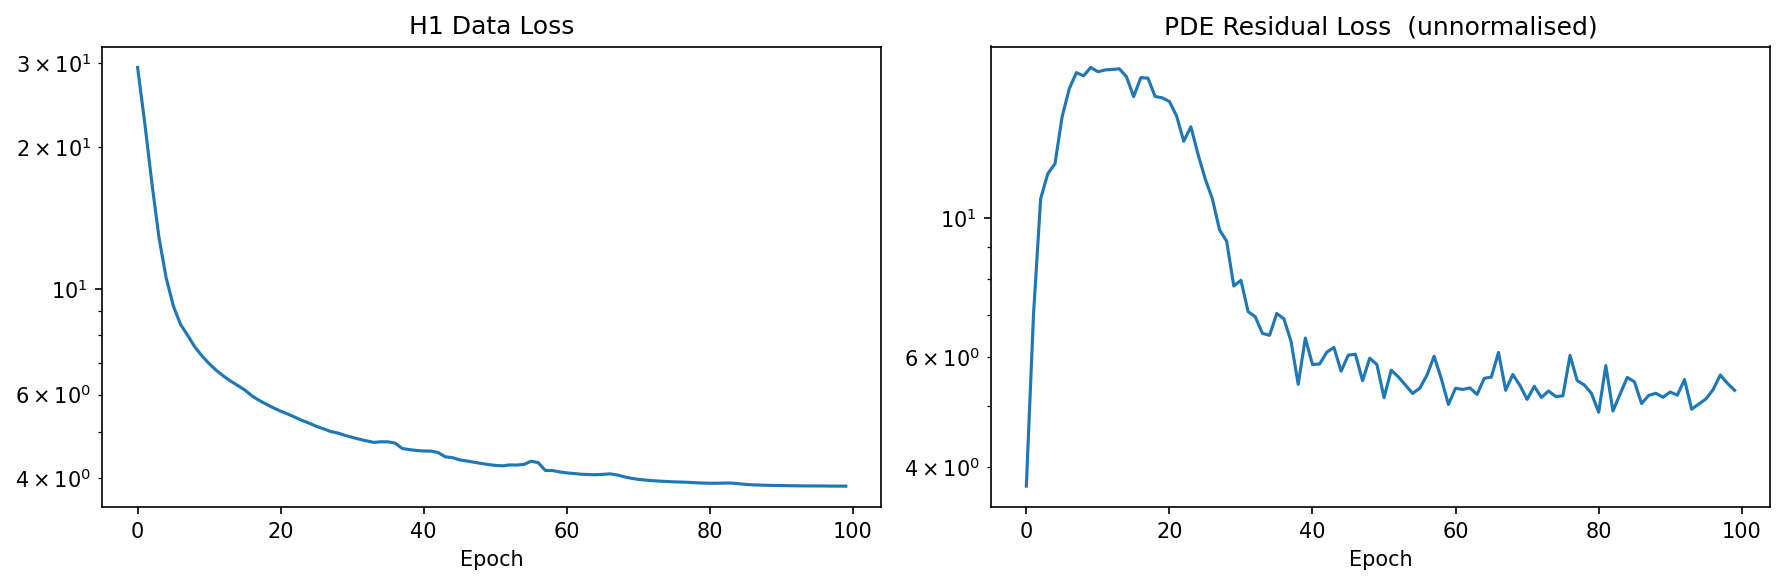

In [168]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

ax1.semilogy(train_loss_history)
ax1.set_title("H1 Data Loss")
ax1.set_xlabel("Epoch")

ax2.semilogy(pde_loss_history)
ax2.set_title("PDE Residual Loss  (unnormalised)")
ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [169]:
model.eval()
with torch.no_grad():
    sample_a = dataset.train_db[0]["x"].unsqueeze(0).to(device)  # a training example
    sample_u_true = dataset.train_db[0]["y"].unsqueeze(0).to(device)
    sample_u_pred = model(sample_a)

print("a range:", sample_a.min().item(), sample_a.max().item())
print("u_true range:", sample_u_true.min().item(), sample_u_true.max().item())
print("u_pred range:", sample_u_pred.min().item(), sample_u_pred.max().item())

a range: 3.0 12.0
u_true range: 1.1645013728411868e-05 1.0680791139602661
u_pred range: -0.06462294608354568 0.8904876112937927


In [170]:
# MCMC helper functions

def log_likelihood(x: torch.Tensor, y: torch.Tensor, model, sigma=0.5275) -> torch.Tensor:
    with torch.no_grad():
        forwards = model(x)[0, 0]   # (Nx, Ny), already on device
    ll = -0.5 * torch.sum((y - forwards) ** 2).item() / sigma**2
    return ll


_x_coords = np.linspace(0, 1, data_train_resolution)
_y_coords = np.linspace(0, 1, data_train_resolution)
_X, _Y = np.meshgrid(_x_coords, _y_coords)
_grid_points = np.column_stack([_X.ravel(), _Y.ravel()])
_gp = GaussianProcessRegressor(kernel=RBF(length_scale=0.3))

def sample_GP():
    sample = _gp.sample_y(_grid_points, n_samples=1, random_state=None)
    return sample.reshape(data_train_resolution, data_train_resolution)


_kernel = Matern(length_scale=0.3, nu=1)
K_1d = _kernel(_x_coords.reshape(-1, 1))
K_1d += 1e-6 * np.eye(len(K_1d))
L_1d = np.linalg.cholesky(K_1d)

def sample_GP_kronecker():
    Z = np.random.randn(data_train_resolution, data_train_resolution)
    return L_1d @ Z @ L_1d.T

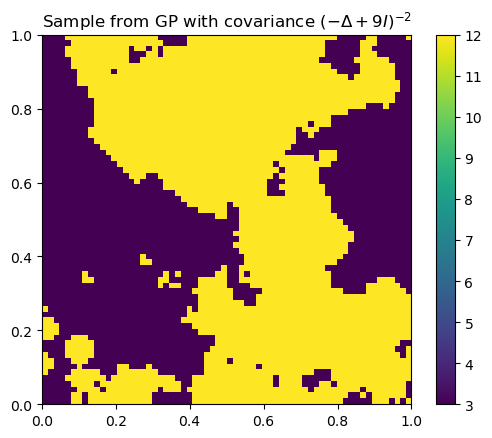

In [171]:
sample = sample_GP_operator()
plt.imshow(T_push(sample_GP_operator(), tau=-1), extent=[0,1,0,1], origin='lower')
plt.colorbar()
plt.title(r'Sample from GP with covariance $(-\Delta + 9I)^{-2}$')
plt.show()

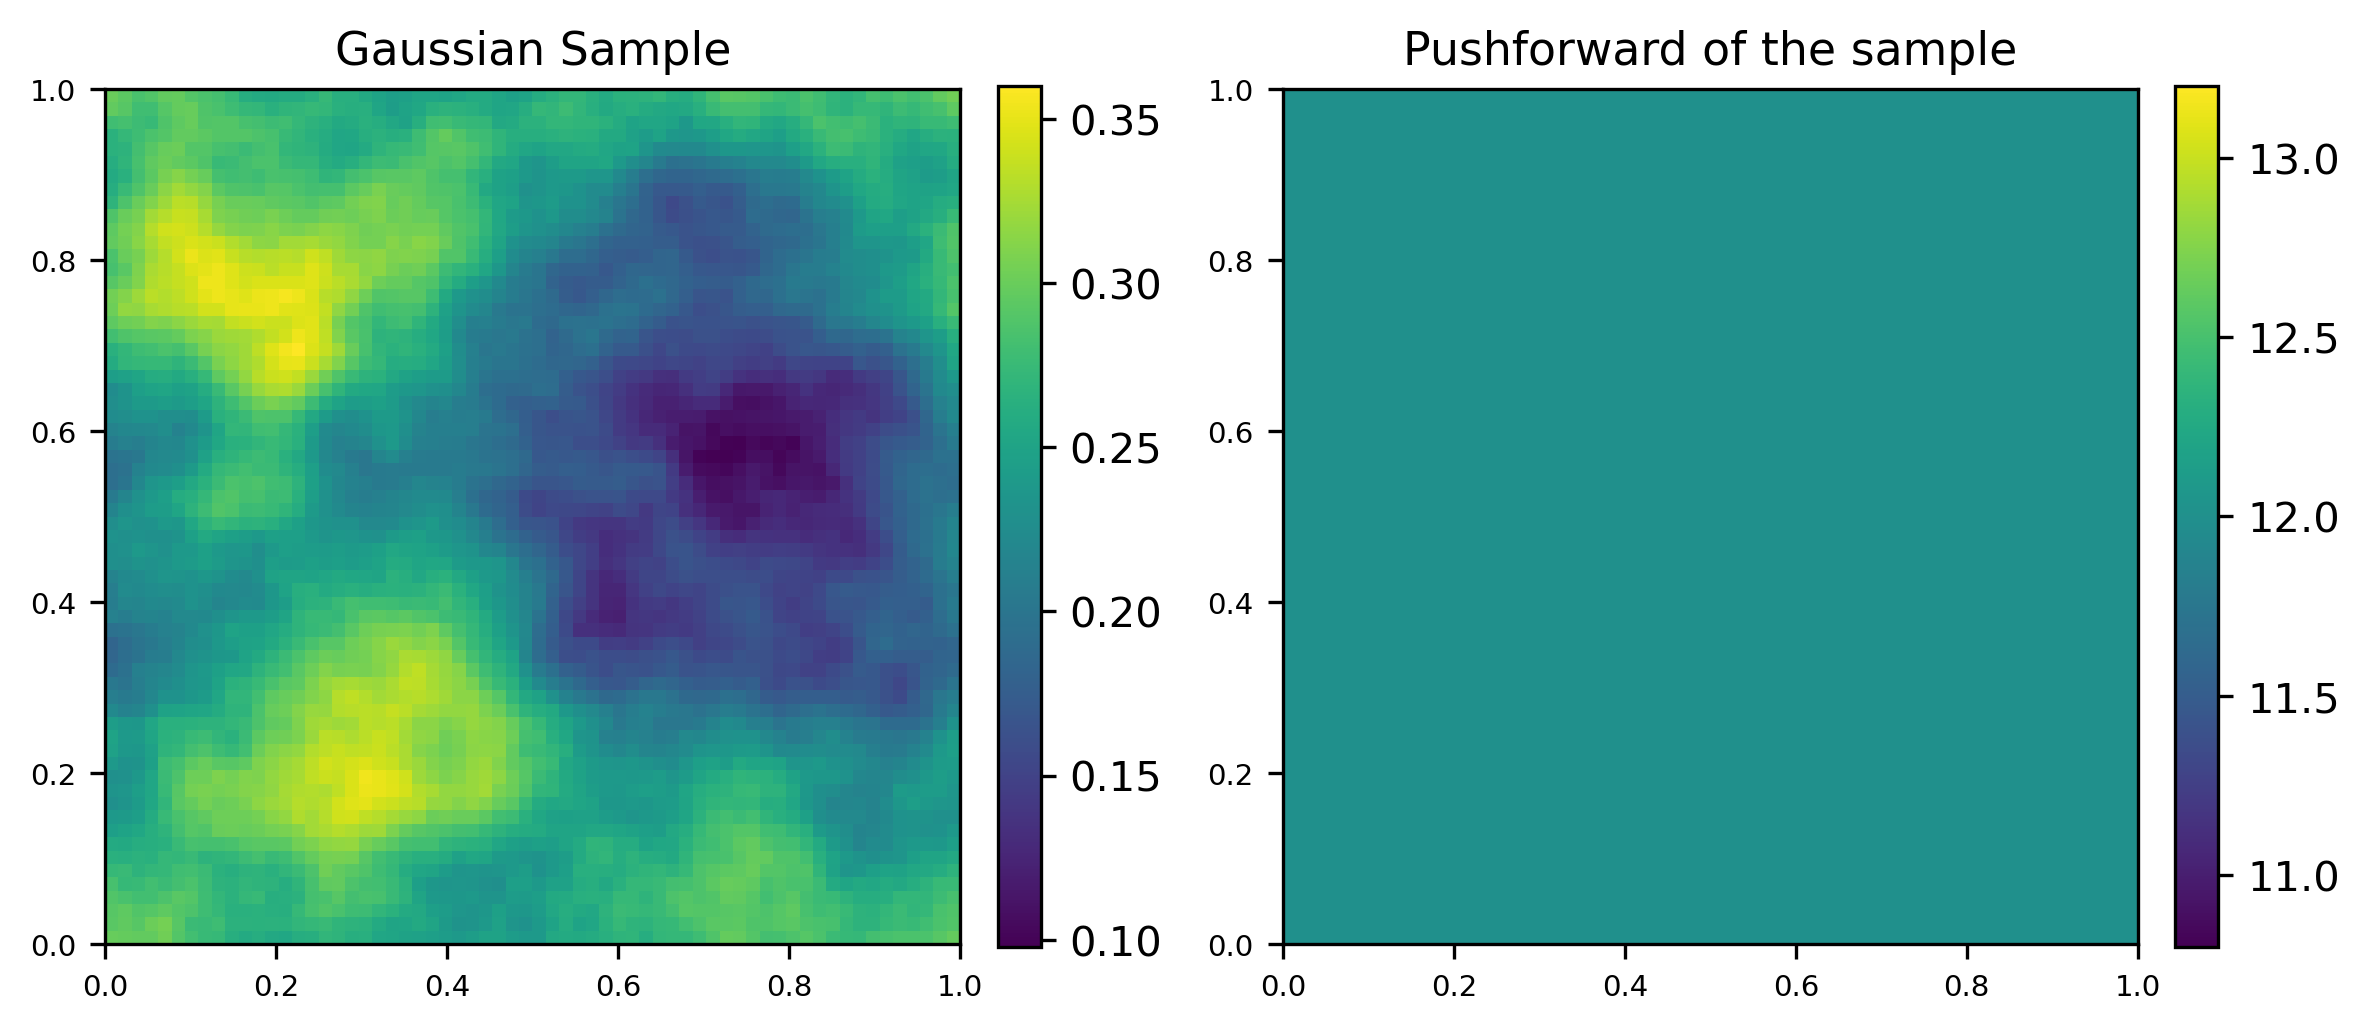

In [172]:
# FINAL REPORT: visualize the sample and its pushforward under T

tf1 = sample_GP_operator(M=256)
tf2 = T_push(tf1, tau=-1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)
for ax, tf, label in zip(axs, [tf1, tf2], ["Gaussian Sample", "Pushforward of the sample"]):
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    im = ax.imshow(tf, extent=[0, 1, 0, 1], origin='lower', vmin=tf.min(), vmax=tf.max())
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [173]:
# Get true field from test set
true_field = dataset.test_dbs[data_train_resolution].x[0, 0].unsqueeze(0).unsqueeze(0)
true_observations = dataset.test_dbs[data_train_resolution].y[0, 0].unsqueeze(0).unsqueeze(0)
sigma = true_observations.std().item()

accepted = 0
u_0 = sample_GP_operator()
theta_0 = T_push(u_0, tau=-1)
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
theta_evolution = [theta_0]
loss_evolution = []
accepted = []

In [ ]:
from collections import deque

# === MCMC HYPERPARAMETERS ===
MCMC_delta      = 0.00025
MCMC_n_iterations = 40_000
MCMC_tau        = -1

target_acceptance = 0.234
adapt_interval    = 500
adapt_cutoff      = 20_000
delta_min, delta_max = 1e-6, 0.49

nll_window        = deque(maxlen=200)
n_accepted_window = 0
adapting          = True

theta_evolution = []
loss_evolution  = []
accepted        = []

true_observations = dataset.test_dbs[64].y[0, 0].unsqueeze(0).unsqueeze(0).to(device)

u_0            = sample_GP_operator(N=64)
theta_0        = T_push(u_0, tau=-1)
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_current     = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)

for i in range(MCMC_n_iterations):
    u_proposal        = np.sqrt(1 - 2 * MCMC_delta) * u_0 + np.sqrt(2 * MCMC_delta) * sample_GP_operator(N=64)
    theta_proposal    = T_push(u_proposal, tau=MCMC_tau)
    theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    ll_proposal      = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
    acceptance_prob  = min(1, np.exp(ll_proposal - ll_current))

    if np.random.rand() < acceptance_prob:
        theta_0        = theta_proposal
        u_0            = u_proposal
        theta_0_tensor = theta_proposal_tensor
        ll_current     = ll_proposal
        accepted.append(1)
        n_accepted_window += 1
    else:
        accepted.append(0)

    theta_evolution.append(theta_0)
    loss_evolution.append(ll_current)
    nll_window.append(-ll_current)

    if (i + 1) % adapt_interval == 0:
        acceptance_rate   = n_accepted_window / adapt_interval
        n_accepted_window = 0
        if adapting:
            factor     = np.exp(acceptance_rate - target_acceptance)
            MCMC_delta = float(np.clip(MCMC_delta * factor, delta_min, delta_max))
            if (i + 1) >= adapt_cutoff:
                adapting = False
                print(f">>> Adaptation frozen at delta={MCMC_delta:.6f}")
        avg_nll = np.mean(nll_window)
        print(f"Iteration {i+1}/{MCMC_n_iterations} | "
              f"accept={acceptance_rate:.3f} | "
              f"delta={MCMC_delta:.6f} | "
              f"adapting={adapting} | "
              f"avg NLL (last 200)={avg_nll:.3f}")

Iteration 500/40000 | accept=0.326 | delta=0.000274 | adapting=True | avg NLL (last 200)=984.193
Iteration 1000/40000 | accept=0.224 | delta=0.000271 | adapting=True | avg NLL (last 200)=294.871
Iteration 1500/40000 | accept=0.140 | delta=0.000247 | adapting=True | avg NLL (last 200)=182.401
Iteration 2000/40000 | accept=0.066 | delta=0.000209 | adapting=True | avg NLL (last 200)=164.162
Iteration 2500/40000 | accept=0.160 | delta=0.000194 | adapting=True | avg NLL (last 200)=122.195
Iteration 3000/40000 | accept=0.120 | delta=0.000173 | adapting=True | avg NLL (last 200)=101.206
Iteration 3500/40000 | accept=0.164 | delta=0.000161 | adapting=True | avg NLL (last 200)=89.950
Iteration 4000/40000 | accept=0.172 | delta=0.000152 | adapting=True | avg NLL (last 200)=81.584
Iteration 4500/40000 | accept=0.222 | delta=0.000150 | adapting=True | avg NLL (last 200)=69.851
Iteration 5000/40000 | accept=0.240 | delta=0.000151 | adapting=True | avg NLL (last 200)=61.285
Iteration 5500/40000 | ac

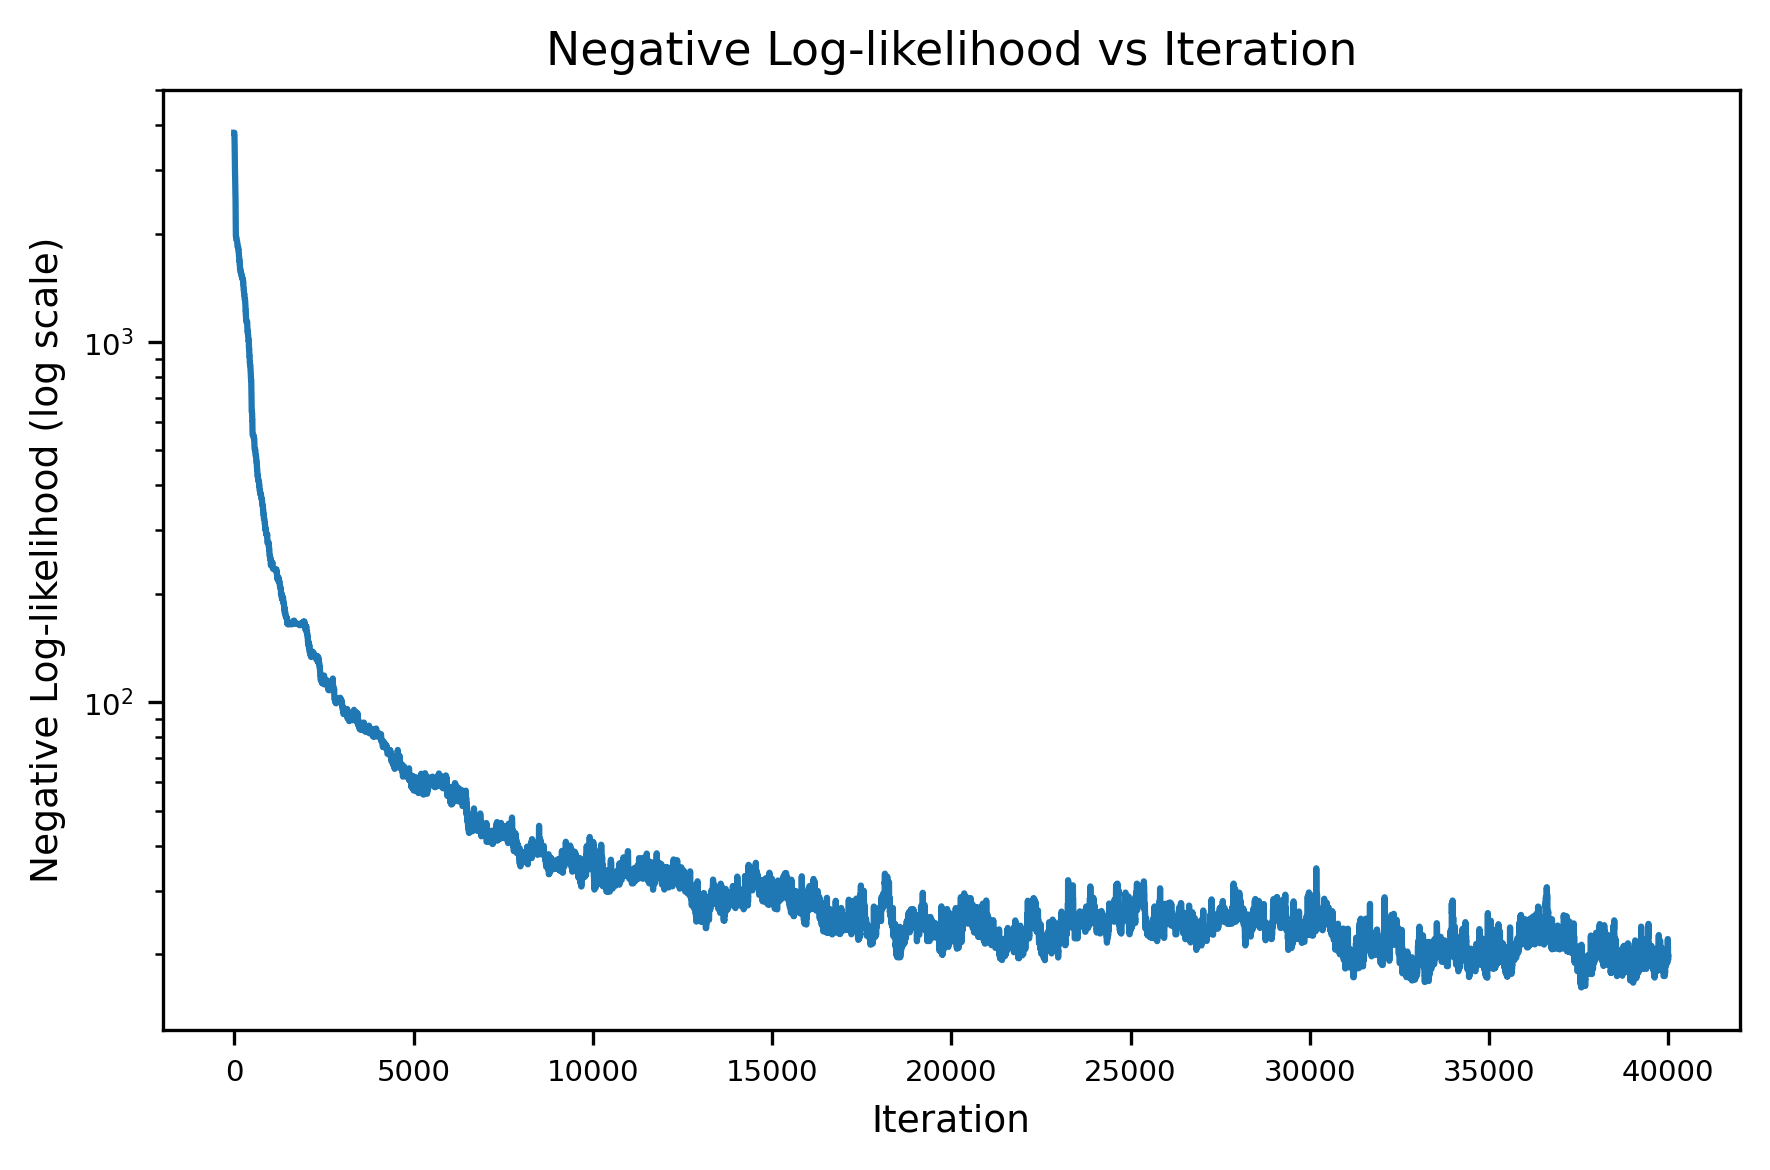

In [175]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
ax.plot(-np.array(loss_evolution))
ax.set_yscale('log')
ax.set_title("Negative Log-likelihood vs Iteration", fontsize=11, loc='center', pad=6)
ax.set_xlabel("Iteration", fontsize=9)
ax.set_ylabel("Negative Log-likelihood (log scale)", fontsize=9)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

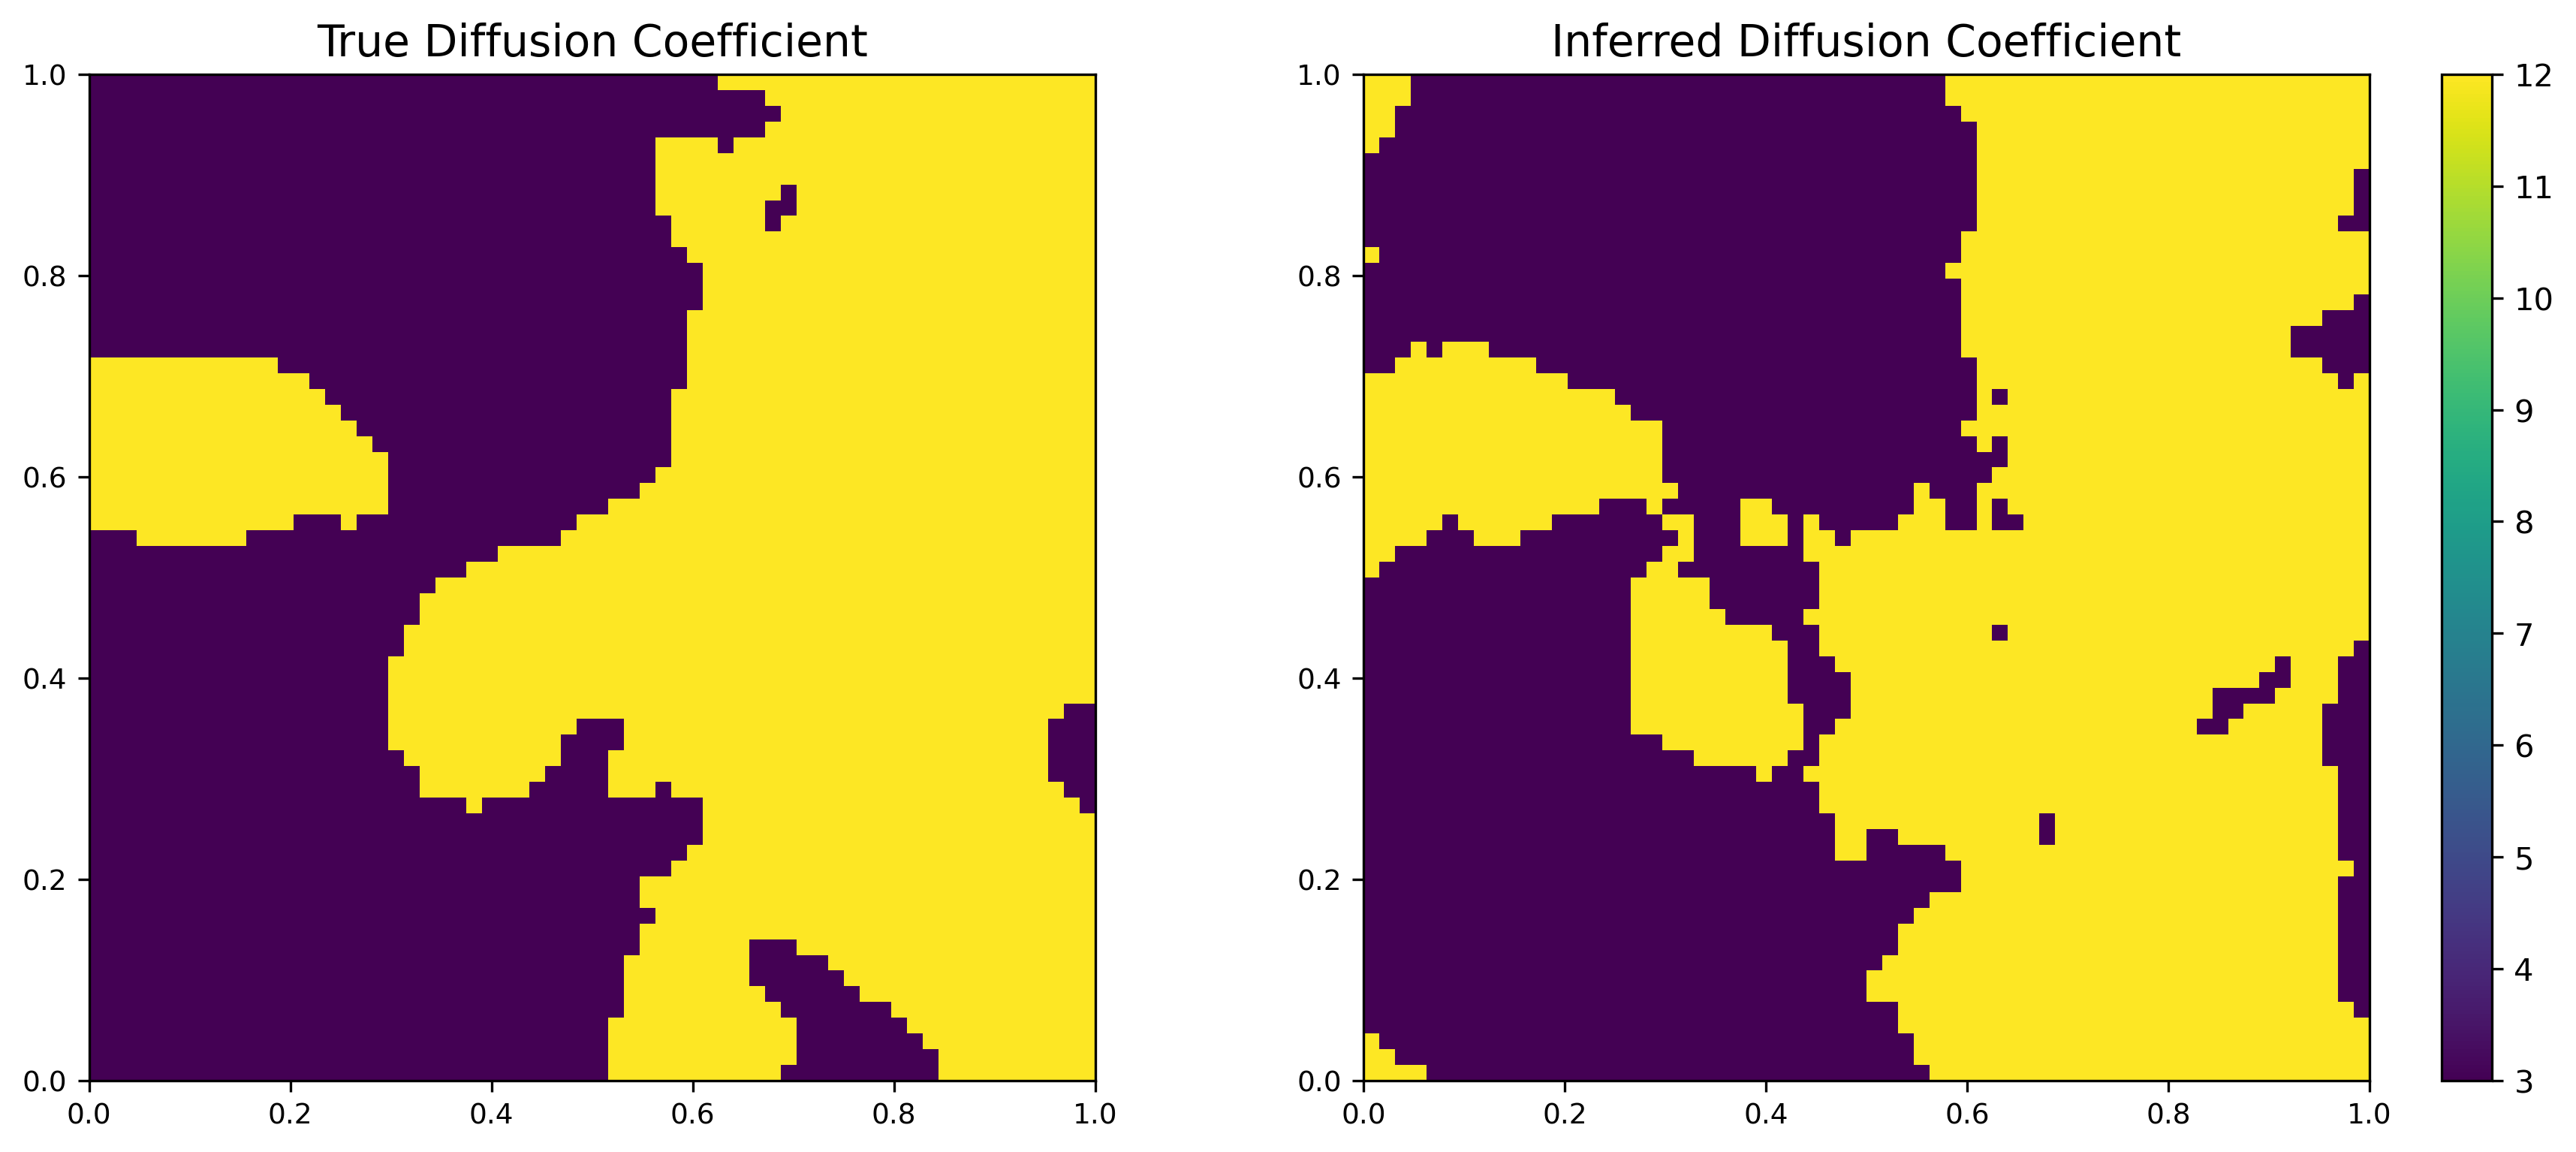

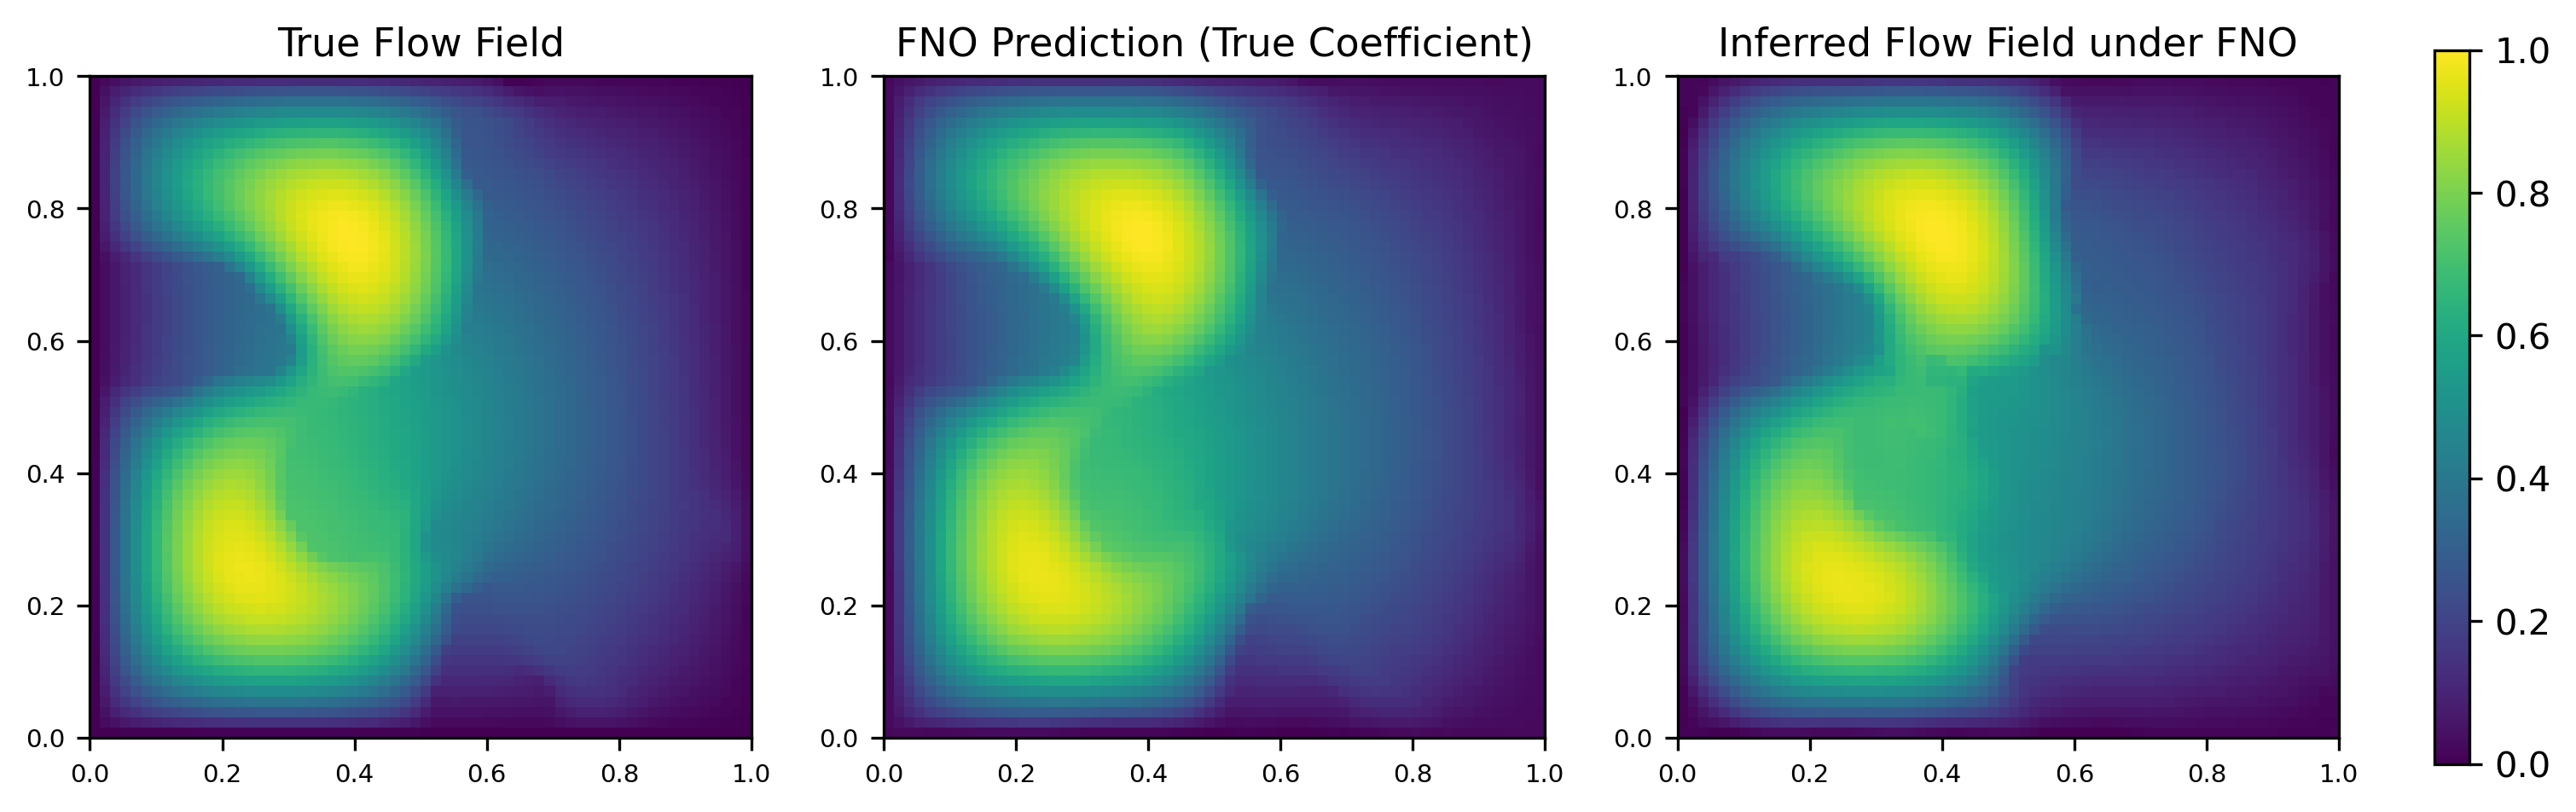

In [176]:
with torch.no_grad():
    forwards = model(true_field[0,0].unsqueeze(0).unsqueeze(0).to(device))

average_predicted_field = T_push(torch.from_numpy(np.mean(theta_evolution[-1:], axis=0)), tau=-1, boundary=7.5).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
    predicted_solution = model(average_predicted_field.to(device)).cpu().numpy()[0, 0]

average_predicted_field = average_predicted_field.squeeze(0).squeeze(0)
fno_prediction = forwards.cpu().numpy()[0, 0]

fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300, constrained_layout=True)
fields1 = [true_field.cpu().numpy()[0, 0], average_predicted_field]
titles1 = ["True Diffusion Coefficient", "Inferred Diffusion Coefficient"]
for ax, field, title in zip(axs1, fields1, titles1):
    im = ax.imshow(field, extent=[0, 1, 0, 1], origin='lower')
    ax.set_title(title, fontsize=14, loc='center', pad=6)
    ax.tick_params(labelsize=9)
fig1.colorbar(im, ax=axs1, fraction=0.03, pad=0.02, shrink=1.0, aspect=20)
plt.show()

fig2, axs2 = plt.subplots(1, 3, figsize=(12, 4), dpi=300)
fields2 = [true_observations.cpu().numpy()[0, 0], fno_prediction, predicted_solution]
titles2 = ["True Flow Field", "FNO Prediction (True Coefficient)", "Inferred Flow Field under FNO"]
for ax, field, title in zip(axs2, fields2, titles2):
    field_norm = (field - field.min()) / (field.max() - field.min())
    im = ax.imshow(field_norm, extent=[0, 1, 0, 1], origin='lower', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.tick_params(labelsize=7)
fig2.colorbar(im, ax=axs2, fraction=0.015, pad=0.04)
plt.show()

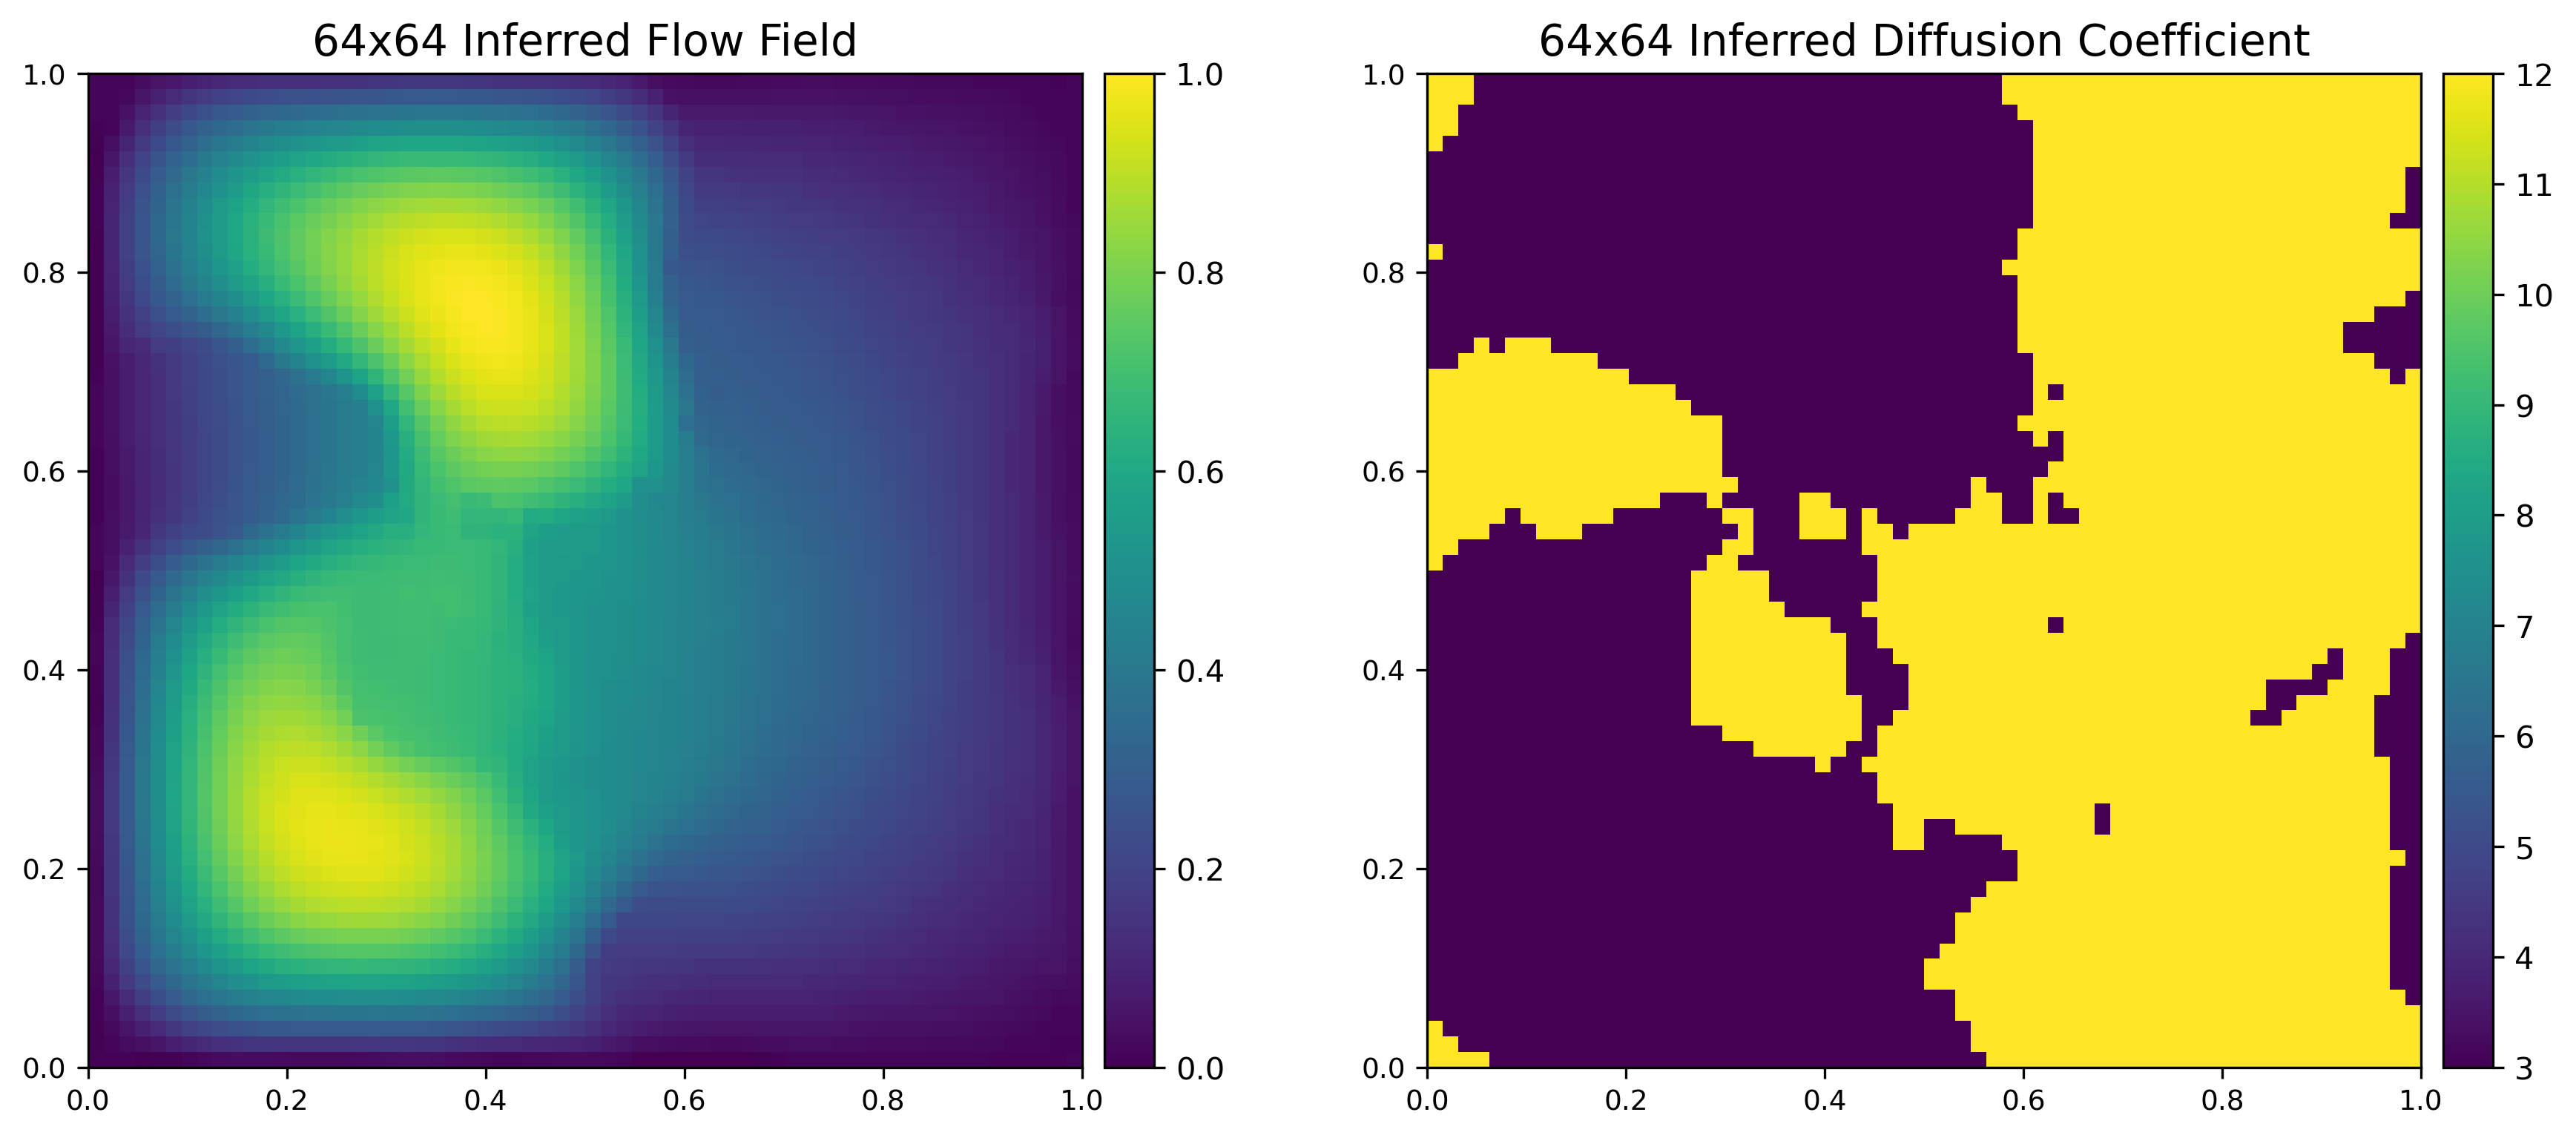

In [177]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300, constrained_layout=True)

flow_field = predicted_solution
flow_field_norm = (flow_field - flow_field.min()) / (flow_field.max() - flow_field.min())
im0 = axs[0].imshow(flow_field_norm, extent=[0, 1, 0, 1], origin='lower', vmin=0, vmax=1)
axs[0].set_title("64x64 Inferred Flow Field", fontsize=14, loc='center', pad=6)
axs[0].tick_params(labelsize=9)
divider0 = make_axes_locatable(axs[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im0, cax=cax0)

diff_field = average_predicted_field
im1 = axs[1].imshow(diff_field, extent=[0, 1, 0, 1], origin='lower')
axs[1].set_title("64x64 Inferred Diffusion Coefficient", fontsize=14, loc='center', pad=6)
axs[1].tick_params(labelsize=9)
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im1, cax=cax1)

# plt.savefig('figures_for_report/super_res_combined_inferred.png', bbox_inches='tight', dpi=300)
plt.show()

In [178]:
# FNO error on the true coefficient
true_field = dataset.test_dbs[64].x[0, 0].unsqueeze(0).unsqueeze(0)
theta_true_tensor = torch.tensor(true_field.cpu().numpy()[0, 0], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_true = log_likelihood(theta_true_tensor, true_observations, model, sigma=sigma)
print(f"NLL with true coefficient: {ll_true:.2f}")
print(f"NLL of MCMC solution:      {ll_current:.2f}")

NLL with true coefficient: -6.37
NLL of MCMC solution:      -19.60


In [179]:
# Losses
pred = torch.tensor(predicted_solution).unsqueeze(0).unsqueeze(0)
pred_norm = (pred - pred.min()) / (pred.max() - pred.min())
obs = true_observations.cpu()[0, 0]
obs_norm = (obs - obs.min()) / (obs.max() - obs.min())
obs_norm = obs_norm.unsqueeze(0).unsqueeze(0)

h1_pred = h1loss(pred_norm, obs_norm)
l2_pred = l2loss(pred_norm, obs_norm)
print(f"H1 Loss of MCMC solution: {h1_pred.item():.4f}")
print(f"L2 Loss of MCMC solution: {l2_pred.item():.4f}")

with torch.no_grad():
    FNO_predicted_true = model(theta_true_tensor).cpu()[0, 0]

fno_norm = (FNO_predicted_true - FNO_predicted_true.min()) / (FNO_predicted_true.max() - FNO_predicted_true.min())
fno_norm = fno_norm.unsqueeze(0).unsqueeze(0)

h1_true = h1loss(fno_norm, obs_norm)
l2_true = l2loss(fno_norm, obs_norm)
print(f"H1 Loss of true solution: {h1_true.item():.4f}")
print(f"L2 Loss of true solution: {l2_true.item():.4f}")

H1 Loss of MCMC solution: 0.2682
L2 Loss of MCMC solution: 0.0570
H1 Loss of true solution: 0.1163
L2 Loss of true solution: 0.0382


In [180]:
# Estimate a reasonable sigma from the FNO's own error on the true field
with torch.no_grad():
    fno_pred = model(theta_true_tensor)
    residuals = (true_observations - fno_pred[0,0])
    print(f"Suggested sigma: {residuals.std().item():.4f}")

Suggested sigma: 0.0130


Text(0.5, 1.0, 'Mean absolute change per step')

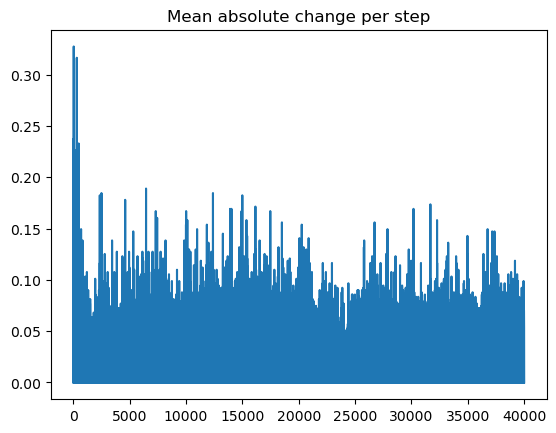

In [181]:
# Plot how much the chain moves each step
diffs = [np.mean(np.abs(theta_evolution[i] - theta_evolution[i-1]))
         for i in range(1, len(theta_evolution))]
plt.plot(diffs)
plt.title("Mean absolute change per step")